# F3NinaE — Sensibilidade temporal: La Niña

**Projeto:** NINO-BRASIL — Oceanografia Física — UFPE  
**Código canônico:** `F3NinaE`  
**Objeto de estudo:** ciclo de vida da La Niña no Pacífico tropical  
**Família de hipótese:** `HIP0`

## 1. Contexto e delimitação científica

Este notebook avalia se os lags e efeitos selecionados são propriedades recorrentes do sinal ou consequências de poucos eventos extremos. A estabilidade entre eventos é indispensável porque a série semanal contém muitas observações, mas poucos eventos independentes.

## 2. Pergunta científica

Os lags selecionados permanecem estáveis quando eventos inteiros são retirados?

## 3. Hipótese específica

Os precursores fisicamente robustos de La Niña mantêm direção e uma faixa de lag semelhante quando eventos completos são reamostrados ou retirados; relações dominadas por um único evento devem perder estabilidade.

A hipótese poderá ser sustentada, parcialmente sustentada ou rejeitada; a execução do notebook não antecipa o resultado.

## 4. Motivação para o teste e unidade de análise

O bootstrap reamostra eventos inteiros e repete a seleção de lag dentro de cada réplica; o leave-one-event-out mede influência individual. Essa estratégia respeita dependência intrassistêmica e não converte semanas correlacionadas em tamanho amostral artificial.

## 5. Metodologia

Bootstrap por evento e leave-one-event-out; amostras semanais não aumentam o número de eventos independentes.

## 6. Resultados esperados e contrato de saída

Resultados esperados significam produtos necessários para responder à pergunta, não valores ou significâncias presumidos:

- frequência de seleção e distribuição do lag em bootstrap por evento.
- diagnóstico leave-one-event-out de direção e influência.
- identificação auditável de relações estáveis e instáveis.

- figuras públicas iniciadas por `FigF3NinaE`;
- tabelas públicas iniciadas por `TabF3NinaE`;
- primeiro par reservado: `FigF3NinaE1` ↔ `TabF3NinaE1`;
- toda interpretação deve apontar para tabela, run_id, unidade, amostra e limitações.

## 7. Fundamentação científica mínima

1. Roberts, D. R. et al. (2017). Cross-validation strategies for data with temporal, spatial, hierarchical or phylogenetic structure. Ecography, 40, 913–929.
2. Wilks, D. S. (2016). The Stippling Shows Statistically Significant Grid Points. Bulletin of the American Meteorological Society, 97, 2263–2273.

## Premissas de validade e limites de interpretação

- Toda conclusão deve nascer de uma tabela `Tab...` persistida antes da figura correspondente.
- A execução é determinística e usa somente entradas declaradas no inventário mostrado abaixo.
- Notebook executado não implica hipótese confirmada; gates científicos são exibidos como resultados.
- El Niño e La Niña são analisados isoladamente; nenhum composto mistura os dois sinais.
- Evento é a unidade independente; semanas descrevem a trajetória interna do evento.

In [1]:
from pathlib import Path
import os
import sys
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'pyproject.toml').exists())
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))
NOTEBOOK_CODE = 'F3NinaE'
MODE = os.environ.get('NINO26_NOTEBOOK_MODE', 'official')
RUN_PIPELINE = os.environ.get('NINO26_RUN_PIPELINE', '0') == '1'
if RUN_PIPELINE:
    raise RuntimeError('O núcleo numérico deve ser executado pelo runner da fase, antes do notebook.')
from nino_brasil.notebook_workflows import NotebookWorkflow
workflow = NotebookWorkflow(ROOT, NOTEBOOK_CODE, mode=MODE)
workflow.describe()

{
  "notebook_code": "F3NinaE",
  "phase": 3,
  "enso_type": "la_nina",
  "mode": "official",
  "execution_policy": "numeric-core-first-viewer-publisher"
}


{'notebook_code': 'F3NinaE',
 'phase': 3,
 'enso_type': 'la_nina',
 'mode': 'official',
 'execution_policy': 'numeric-core-first-viewer-publisher'}

## Dados

In [2]:
input_inventory = workflow.input_inventory()
display(input_inventory)
workflow.require_inputs()

,role,path,required,exists,bytes
0,bootstrap de eventos,data\processed\parquet\statistics\F3Nina\TabF3...,True,True,149981


## Resultados

,notebook_code,ordinal,namespace,figure_code,table_code,figure_path,table_path,manifest_path,figure_sha256,table_sha256,run_id
0,F3NinaE,1,fase3_nina,FigF3NinaE1,TabF3NinaE1,C:\DEV\NINO26\data\processed\figures\fase3_nin...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,C:\DEV\NINO26\data\processed\numeric-tables\fa...,7c332a75c37909209fe42a17509fe865741be54c5bd0a6...,1a54638aa722c2b738df19e1775b208d9dc1770d8bca3c...,20260714T202702Z_5538a635


,tipo,fase,variavel_alvo,n_precursores_candidatos,aliases_alvo_excluidos,bootstrap_screening_rank,bootstrap_screening_top_k,bootstrap_screening_rule,lag_semanas,n_eventos_independentes,...,vezes_selecionado,frequencia_selecao,r_mediano_quando_selecionado,r_ic95_inf_quando_selecionado,r_ic95_sup_quando_selecionado,resampling_unit,lag_selection_repeated_inside_bootstrap,condition_time,variavel,n_precursores_fdr_na_familia
0,la_nina,crescimento,nino34_ssta,30,nino34_ssta,1,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,0,11,...,492,0.492,0.489135,0.315958,0.624467,evento_enso_completo,True,source,tcwv_anom,8
1,la_nina,crescimento,nino34_ssta,30,nino34_ssta,1,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,1,11,...,8,0.008,0.552135,0.486551,0.633989,evento_enso_completo,True,source,tcwv_anom,8
2,la_nina,crescimento,nino34_ssta,30,nino34_ssta,1,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,2,11,...,2,0.002,0.582176,0.535839,0.628514,evento_enso_completo,True,source,tcwv_anom,8
3,la_nina,crescimento,nino34_ssta,30,nino34_ssta,1,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,3,11,...,0,0.000,NaN,NaN,NaN,evento_enso_completo,True,source,tcwv_anom,8
4,la_nina,crescimento,nino34_ssta,30,nino34_ssta,1,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,4,11,...,0,0.000,NaN,NaN,NaN,evento_enso_completo,True,source,tcwv_anom,8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,la_nina,crescimento,nino34_ssta,30,nino34_ssta,2,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,42,11,...,24,0.024,-0.431142,-0.526987,-0.326755,evento_enso_completo,True,source,ssr_anom,8
96,la_nina,crescimento,nino34_ssta,30,nino34_ssta,2,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,43,11,...,0,0.000,NaN,NaN,NaN,evento_enso_completo,True,source,ssr_anom,8
97,la_nina,crescimento,nino34_ssta,30,nino34_ssta,2,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,44,11,...,1,0.001,0.629630,0.629630,0.629630,evento_enso_completo,True,source,ssr_anom,8
98,la_nina,crescimento,nino34_ssta,30,nino34_ssta,2,5,top_k_por_tipo_fase_apos_bh_fdr_no_scan_original,45,11,...,1,0.001,-0.428936,-0.428936,-0.428936,evento_enso_completo,True,source,ssr_anom,8


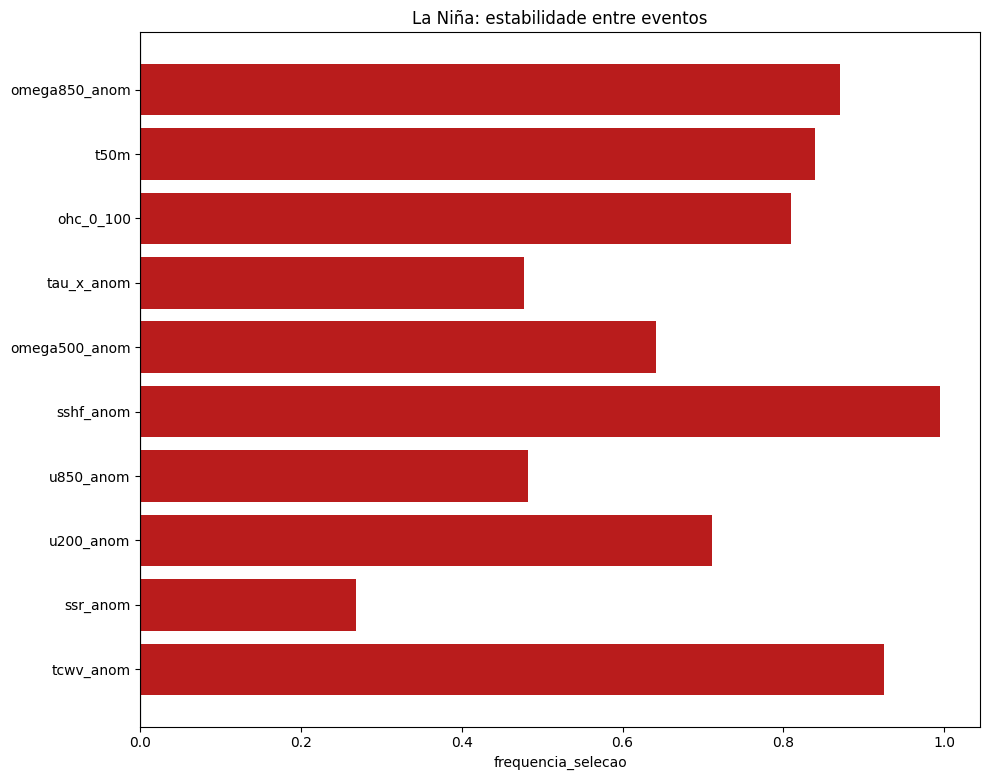

In [3]:
result = workflow.run()
display(result.artifacts)
display(result.summary)

## Figuras para verificação rápida

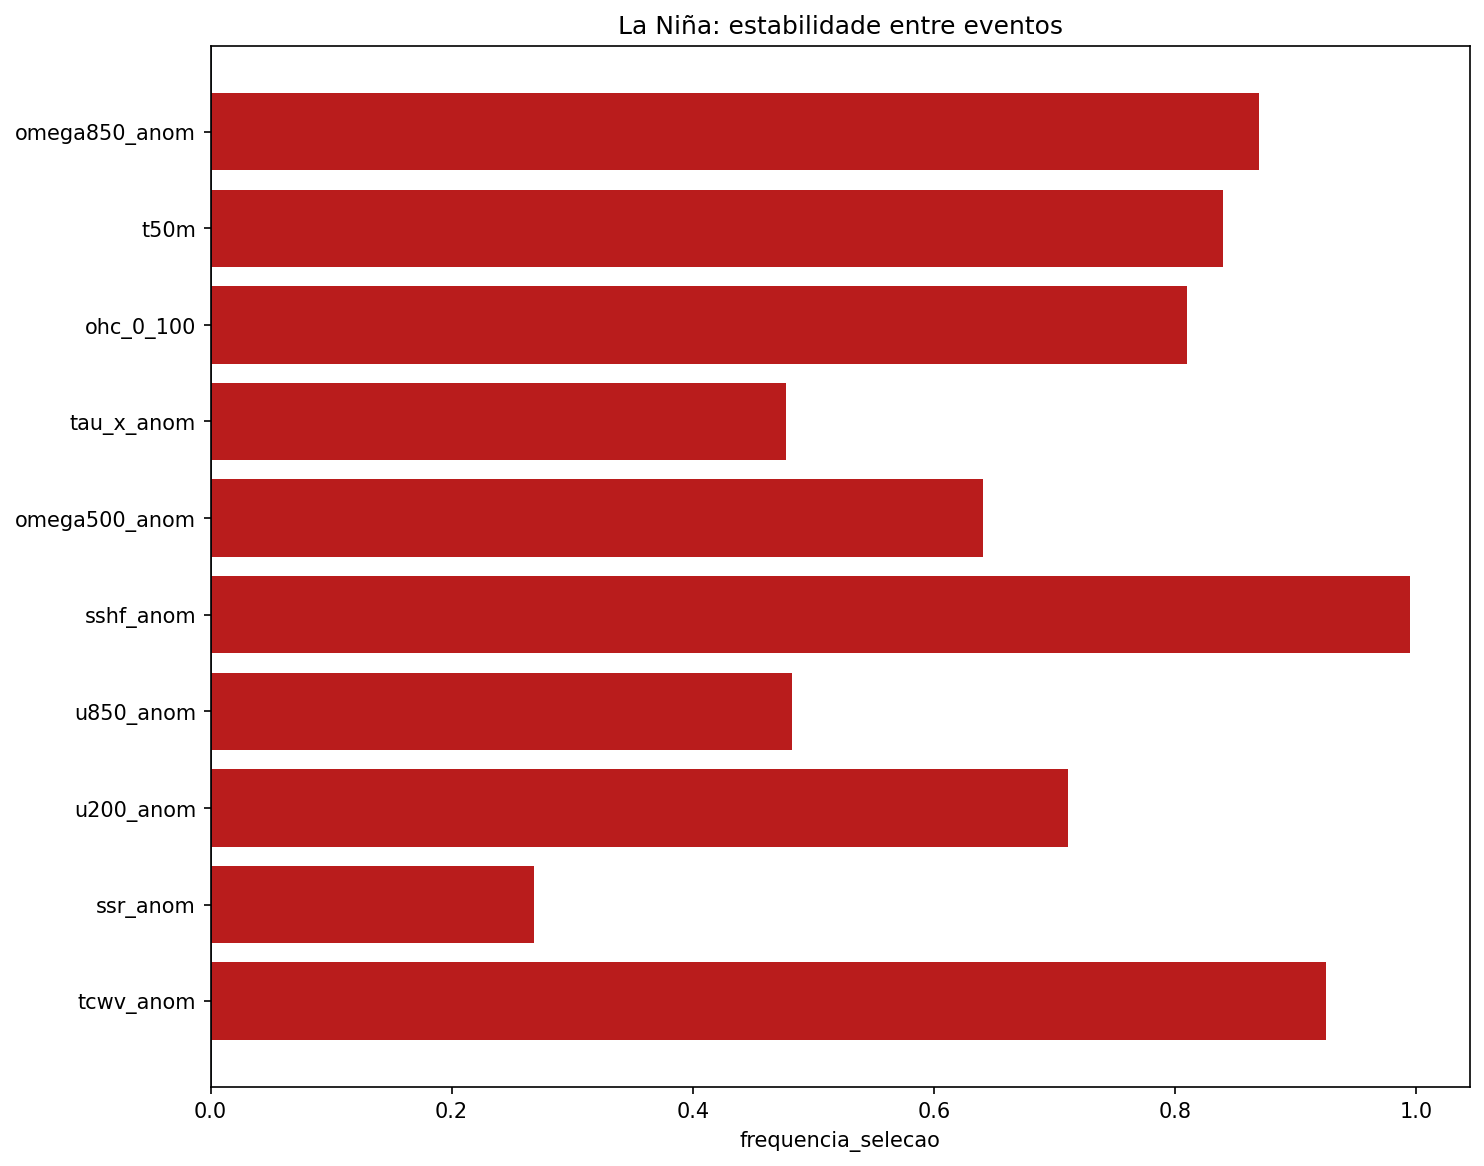

In [4]:
from IPython.display import Image, display

for artifact in result.artifacts.itertuples(index=False):
    display(Image(filename=str(artifact.figure_path)))

## Conclusões

In [5]:
for item in result.takeaways:
    print(f'- {item}')
print('\nLimitações:')
for item in result.limitations:
    print(f'- {item}')

- A tabela auditada contém 795 linhas para La Niña.
- A leitura mantém eventos independentes separados e não soma semanas como novas réplicas.

Limitações:
- A figura resume a tabela publicada; consulte a tabela completa e seu manifesto antes de interpretar valores individuais.
- Resultados negativos ou tabelas vazias são preservados e não são convertidos em falha técnica.
